In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Del-mål og plan

__Pre-prosessering og massasje av data__

*`clean_and_combine.py`*

* Tar inn csv-filer med rådata.
* For 3 forsøk per eksperiment: fjerner gjennomsnittet av de 200 første radene fra alle probene, og legger på et low-pass filter som fjerner høy-frekeventer og støyete signal. Det gjøres med en weighted moving average. Denne delen av koden er tatt fra Maxime, men skrevet om til å funke med min stil.
* Så kombineres de tre forsøkene av samme eksperiment inn til en ny csv-fil som da er gjennomsnittet av de behandleded forsøkene.

__Beregne variabler__

*`funcs.py`*

* Ønkser for et gitt eksperiment gitt av:
    - Vanndyp
    - Plate konfigurasjon
    - Frekvens
    - AMplitude

å analysere alle 5 probe posisjoner. Det vil si 5 ulike posisjoner for de 4 individuelle probene langs med tanken. 

* Vil beregne bølgelengde, bølgetall og frekvens ved Fourier transformasjon a signalet.
* Fasehastighet og gruppehastighet (?)
* Finne antall gyldige bølger før refleksjon, sett sammen med hvor bølgene er utviklet.
* Finne standardavvik per probe per probe posisjon (dvs. en virtuell array med 20 prober)
* Beregne høyden (bredden?) på det viskøse grenselaget (gitt av frekvens)
* Beregne dempningskoeffisienten

__Foreløpige problemer__

* Har ikke funnet en god metode for å finne maks antall bølger. Jeg vil gjerne gjøre det "vanntett", men har per nå måttet ta noen empiriske valg ved å se på når bølgen er utviklet. 
* Med foreløpig metode kan det se ut som at det er umulig å unngå refleksjoner i posisjonene lengst nede i tanken.
* For å finne dempningskoeffisient, er det da best å se på gradienten av amplituden i rom? 

The test files here are processed data from runs with 20 cm water depth, frequency 0.76 Hz and amplitude of 0.15 V.

In [39]:
path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test.csv'
pos0 = pd.read_csv(path)

path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_p1.csv'
pos1 = pd.read_csv(path)

path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_p2.csv'
pos2 = pd.read_csv(path)

path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_p3.csv'
pos3 = pd.read_csv(path)

path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_p4.csv'
pos4 = pd.read_csv(path)

In [40]:
path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_no_p0.csv'
pos0_no = pd.read_csv(path)

path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_no_p1.csv'
pos1_no = pd.read_csv(path)

path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_no_p2.csv'
pos2_no = pd.read_csv(path)

path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_no_p3.csv'
pos3_no = pd.read_csv(path)

path = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Test/test_no_p4.csv'
pos4_no = pd.read_csv(path)

Issue: the timestamps are now the timestamps of run 1. Should maybe interpolate??

Text(0.5, 0.98, '20 cm depth, with plates')

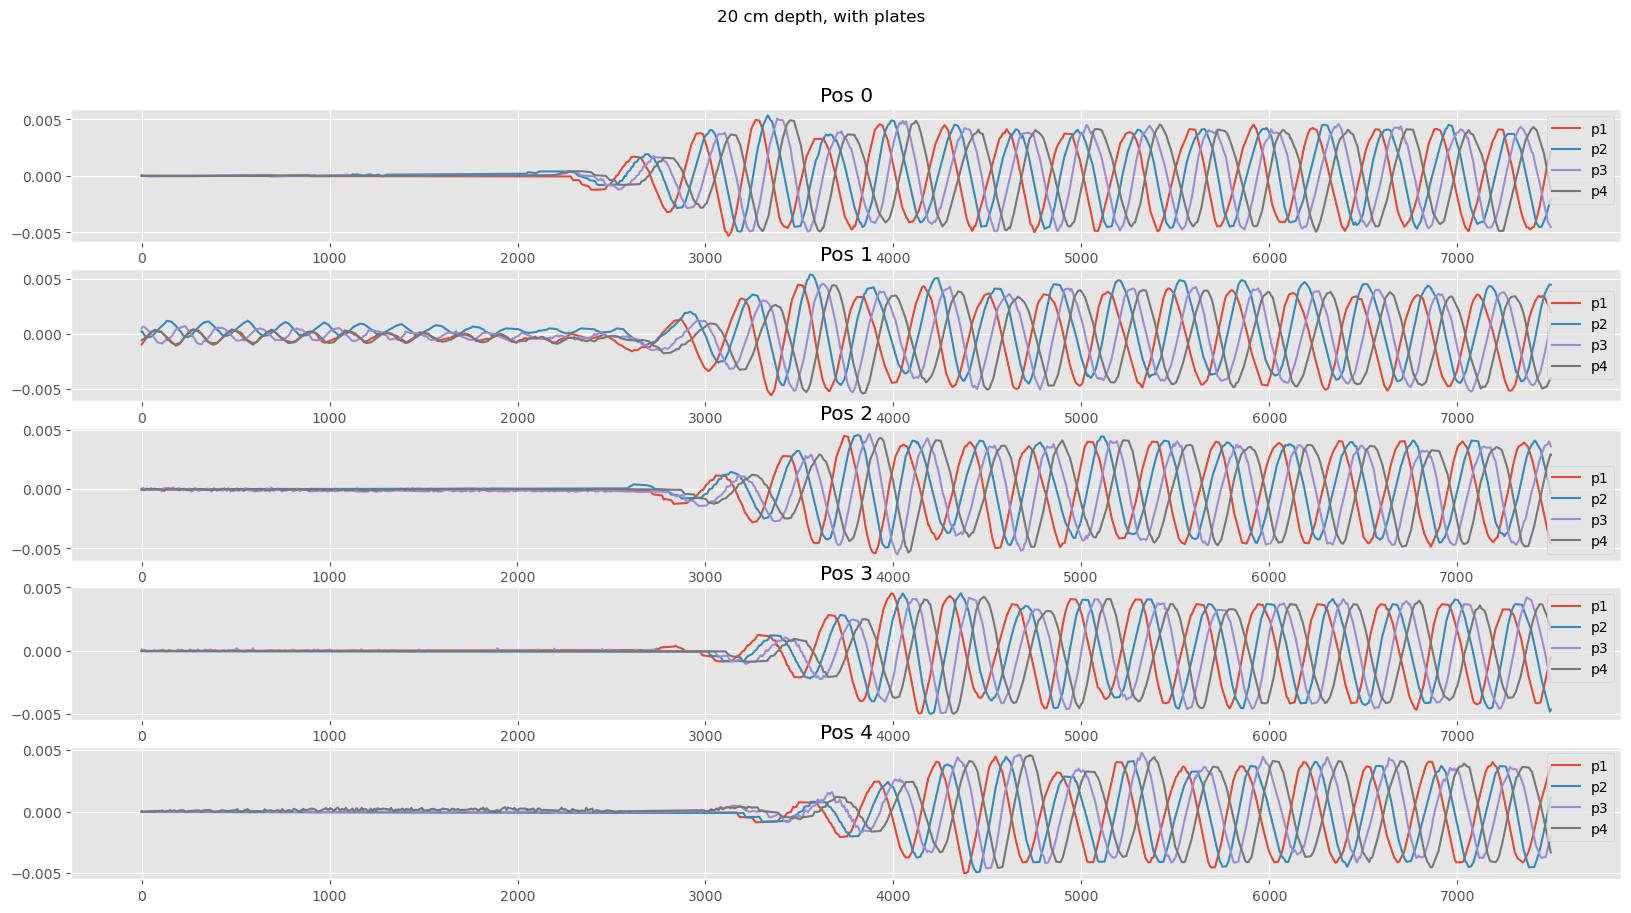

In [41]:
fig, ax = plt.subplots(5, 1, figsize=(20, 10))
ax[0].plot(pos0['p1'], label='p1')
ax[0].plot(pos0['p2'], label='p2')
ax[0].plot(pos0['p3'], label='p3')
ax[0].plot(pos0['p4'], label='p4')

ax[0].legend()

ax[0].set_title('Pos 0')

ax[1].plot(pos1['p1'], label='p1')
ax[1].plot(pos1['p2'], label='p2')
ax[1].plot(pos1['p3'], label='p3')
ax[1].plot(pos1['p4'], label='p4')

ax[1].legend()

ax[1].set_title('Pos 1')

ax[2].plot(pos2['p1'], label='p1')
ax[2].plot(pos2['p2'], label='p2')
ax[2].plot(pos2['p3'], label='p3')
ax[2].plot(pos2['p4'], label='p4')

ax[2].legend()

ax[2].set_title('Pos 2')

ax[3].plot(pos3['p1'], label='p1')
ax[3].plot(pos3['p2'], label='p2')
ax[3].plot(pos3['p3'], label='p3')
ax[3].plot(pos3['p4'], label='p4')

ax[3].legend()

ax[3].set_title('Pos 3')

ax[4].plot(pos4['p1'], label='p1')
ax[4].plot(pos4['p2'], label='p2')
ax[4].plot(pos4['p3'], label='p3')
ax[4].plot(pos4['p4'], label='p4')

ax[4].legend()

ax[4].set_title('Pos 4')

fig.suptitle('20 cm depth, with plates')

Text(0.5, 0.98, '20 cm depth, no plates')

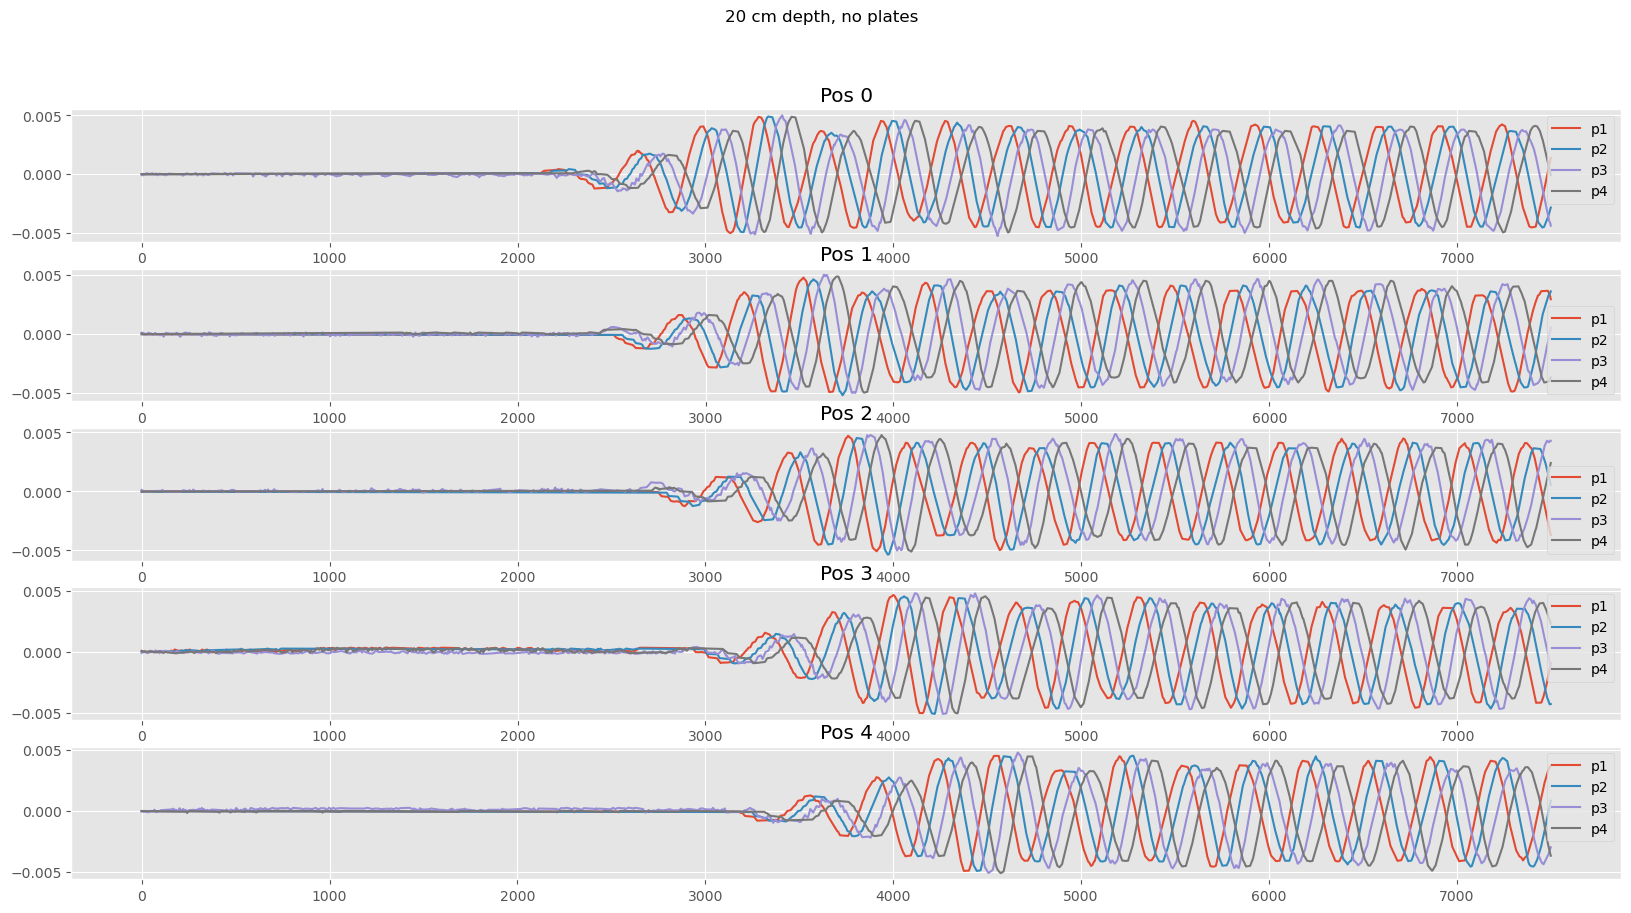

In [42]:
fig, ax = plt.subplots(5, 1, figsize=(20, 10))
ax[0].plot(pos0_no['p1'], label='p1')
ax[0].plot(pos0_no['p2'], label='p2')
ax[0].plot(pos0_no['p3'], label='p3')
ax[0].plot(pos0_no['p4'], label='p4')

ax[0].legend()

ax[0].set_title('Pos 0')

ax[1].plot(pos1_no['p1'], label='p1')
ax[1].plot(pos1_no['p2'], label='p2')
ax[1].plot(pos1_no['p3'], label='p3')
ax[1].plot(pos1_no['p4'], label='p4')

ax[1].legend()

ax[1].set_title('Pos 1')

ax[2].plot(pos2_no['p1'], label='p1')
ax[2].plot(pos2_no['p2'], label='p2')
ax[2].plot(pos2_no['p3'], label='p3')
ax[2].plot(pos2_no['p4'], label='p4')

ax[2].legend()

ax[2].set_title('Pos 2')

ax[3].plot(pos3_no['p1'], label='p1')
ax[3].plot(pos3_no['p2'], label='p2')
ax[3].plot(pos3_no['p3'], label='p3')
ax[3].plot(pos3_no['p4'], label='p4')

ax[3].legend()

ax[3].set_title('Pos 3')

ax[4].plot(pos4_no['p1'], label='p1')
ax[4].plot(pos4_no['p2'], label='p2')
ax[4].plot(pos4_no['p3'], label='p3')
ax[4].plot(pos4_no['p4'], label='p4')

ax[4].legend()

ax[4].set_title('Pos 4')

fig.suptitle('20 cm depth, no plates')

I have now loaded in 10 dataframes. 5 dataframes with plates, where they differ in probe positions along the tank. 5 dataframes without plates, again they differ in where the probes where placed in the tank.

In [43]:
# Actual positions of the virtual array of probes
X_base = np.array([11.075, 11.38, 11.685, 11.99])  # Base positions [m]
offset = 1.215  # distance each probe is moved between positions

# Number of position sets
num_positions = 5

# Create the array of all positions
x_probe_pos = np.array([X_base + offset * i for i in range(num_positions)]).flatten()

In [44]:
lamb_pos0, f_pos0 = estimate_wavelength(pos0, x_probe_pos[0:4])
lamb_pos0_no, f_pos0_no = estimate_wavelength(pos0_no, x_probe_pos[0:4])

In [45]:
lamb_pos1, f_pos1 = estimate_wavelength(pos1, x_probe_pos[4:8])
lamb_pos1_no, f_pos1_no = estimate_wavelength(pos1_no, x_probe_pos[4:8])

In [46]:
lamb_pos2, f_pos2 = estimate_wavelength(pos2, x_probe_pos[8:12])
lamb_pos2_no, f_pos2_no = estimate_wavelength(pos2_no, x_probe_pos[8:12])

In [47]:
lamb_pos3, f_pos3 = estimate_wavelength(pos3, x_probe_pos[12:16])
lamb_pos3_no, f_pos3_no = estimate_wavelength(pos3_no, x_probe_pos[12:16])

In [48]:
lamb_pos4, f_pos4 = estimate_wavelength(pos4, x_probe_pos[16:])
lamb_pos4_no, f_pos4_no = estimate_wavelength(pos4_no, x_probe_pos[16:])

In [49]:
# Checking that everything looks correct
print('Dominant frequency found by Fourier transform for all probe positions')
print(f'Position 0 with plates {f_pos0:.2f} Hz, no plates {f_pos0_no:.2f} Hz')
print(f'Position 1 with plates {f_pos1:.2f} Hz, no plates {f_pos1_no:.2f} Hz')
print(f'Position 2 with plates {f_pos2:.2f} Hz, no plates {f_pos2_no:.2f} Hz')
print(f'Position 3 with plates {f_pos3:.2f} Hz, no plates {f_pos3_no:.2f} Hz')
print(f'Position 4 with plates {f_pos4:.2f} Hz, no plates {f_pos4_no:.2f} Hz')

Dominant frequency found by Fourier transform for all probe positions
Position 0 with plates 0.77 Hz, no plates 0.77 Hz
Position 1 with plates 0.77 Hz, no plates 0.77 Hz
Position 2 with plates 0.77 Hz, no plates 0.77 Hz
Position 3 with plates 0.77 Hz, no plates 0.77 Hz
Position 4 with plates 0.77 Hz, no plates 0.77 Hz


In [50]:
# Checking that everything looks correct
print('Wavelength found by Fourier transform for all probe positions')
print(f'Position 0 with plates {lamb_pos0:.2f} m, no plates {lamb_pos0_no:.2f} m')
print(f'Position 1 with plates {lamb_pos1:.2f} m, no plates {lamb_pos1_no:.2f} m')
print(f'Position 2 with plates {lamb_pos2:.2f} m, no plates {lamb_pos2_no:.2f} m')
print(f'Position 3 with plates {lamb_pos3:.2f} m, no plates {lamb_pos3_no:.2f} m')
print(f'Position 4 with plates {lamb_pos4:.2f} m, no plates {lamb_pos4_no:.2f} m')

Wavelength found by Fourier transform for all probe positions
Position 0 with plates 1.69 m, no plates 1.68 m
Position 1 with plates 1.66 m, no plates 1.67 m
Position 2 with plates 1.66 m, no plates 1.68 m
Position 3 with plates 1.66 m, no plates 1.67 m
Position 4 with plates 1.68 m, no plates 1.67 m


In [51]:
max_waves_pos0 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos0, wavelength=lamb_pos0, probe_positions=x_probe_pos[0:4], wave_maker_build_up_time=3250 * 0.004)
max_waves_pos0_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos0_no, wavelength=lamb_pos0_no, probe_positions=x_probe_pos[0:4], wave_maker_build_up_time=3250 * 0.004)

In [52]:
max_waves_pos1 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos1, wavelength=lamb_pos1, probe_positions=x_probe_pos[4:8], wave_maker_build_up_time=3500 * 0.004)
max_waves_pos1_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos1_no, wavelength=lamb_pos1_no, probe_positions=x_probe_pos[4:8], wave_maker_build_up_time=3500 * 0.004)

In [53]:
max_waves_pos2 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos2, wavelength=lamb_pos2, probe_positions=x_probe_pos[8:12], wave_maker_build_up_time=3750 * 0.004)
max_waves_pos2_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos2_no, wavelength=lamb_pos2_no, probe_positions=x_probe_pos[8:12], wave_maker_build_up_time=3750 * 0.004)

In [54]:
max_waves_pos3 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos3, wavelength=lamb_pos3, probe_positions=x_probe_pos[12:16], wave_maker_build_up_time=4000 * 0.004)
max_waves_pos3_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos3_no, wavelength=lamb_pos3_no, probe_positions=x_probe_pos[12:16], wave_maker_build_up_time=4000 * 0.004)

In [55]:
max_waves_pos4 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos4, wavelength=lamb_pos4, probe_positions=x_probe_pos[16:], wave_maker_build_up_time=4250*0.004)
max_waves_pos4_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos4_no, wavelength=lamb_pos4_no, probe_positions=x_probe_pos[16:], wave_maker_build_up_time=4250*0.004)

Med Maxime sin setup av probene, og for bølger med frekvens 0.76 Hz, 0.15 V amplitude og 20 cm vanndyp:

In [56]:
print('Mean maximum number of waves for probe positions 0 (with plates)', np.mean(max_waves_pos0))
print('Mean maximum number of waves for probe positions 0 (no plates)', np.mean(max_waves_pos0_no))
print()
print('Mean maximum number of waves for probe positions 1 (with plates)', np.mean(max_waves_pos1))
print('Mean maximum number of waves for probe positions 1 (no plates)', np.mean(max_waves_pos1_no))
print()
print('Mean maximum number of waves for probe positions 2 (with plates)', np.mean(max_waves_pos2))
print('Mean maximum number of waves for probe positions 2 (no plates)', np.mean(max_waves_pos2_no))
print()
print('Mean maximum number of waves for probe positions 3 (with plates)', np.mean(max_waves_pos3))
print('Mean maximum number of waves for probe positions 3 (no plates)', np.mean(max_waves_pos3_no))
print()
print('Mean maximum number of waves for probe positions 4 (with plates)', np.mean(max_waves_pos4))
print('Mean maximum number of waves for probe positions 4 (no plates)', np.mean(max_waves_pos4_no))

Mean maximum number of waves for probe positions 0 (with plates) 6.037065422957579
Mean maximum number of waves for probe positions 0 (no plates) 6.048540770838355

Mean maximum number of waves for probe positions 1 (with plates) 3.8638266576641107
Mean maximum number of waves for probe positions 1 (no plates) 3.8436249507082922

Mean maximum number of waves for probe positions 2 (with plates) 1.6527669820503679
Mean maximum number of waves for probe positions 2 (no plates) 1.630164108589097

Mean maximum number of waves for probe positions 3 (with plates) 0.0
Mean maximum number of waves for probe positions 3 (no plates) 0.0

Mean maximum number of waves for probe positions 4 (with plates) 0.0
Mean maximum number of waves for probe positions 4 (no plates) 0.0


Checking to see how many waves there can be without reflections if we move the probes upstream

In [ ]:
# Suggested positions of the virtual array of probes
hypo_X_base = np.array([3, 3.305, 3.610, 3.915])  # Base positions [m]
offset = 1.215  # distance each probe is moved between positions

# Number of position sets
num_positions = 5

# Create the array of all positions
hypo_x_probe_pos = np.array([hypo_X_base + offset * i for i in range(num_positions)]).flatten()

In [75]:
max_waves_pos0 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos0, wavelength=lamb_pos0, probe_positions=hypo_x_probe_pos[0:4], wave_maker_build_up_time=3250 * 0.004)
max_waves_pos0_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos0_no, wavelength=lamb_pos0_no, probe_positions=hypo_x_probe_pos[0:4], wave_maker_build_up_time=3250 * 0.004)

max_waves_pos1 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos1, wavelength=lamb_pos1, probe_positions=hypo_x_probe_pos[4:8], wave_maker_build_up_time=3500 * 0.004)
max_waves_pos1_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos1_no, wavelength=lamb_pos1_no, probe_positions=hypo_x_probe_pos[4:8], wave_maker_build_up_time=3500 * 0.004)

max_waves_pos2 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos2, wavelength=lamb_pos2, probe_positions=hypo_x_probe_pos[8:12], wave_maker_build_up_time=3750 * 0.004)
max_waves_pos2_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos2_no, wavelength=lamb_pos2_no, probe_positions=hypo_x_probe_pos[8:12], wave_maker_build_up_time=3750 * 0.004)

max_waves_pos3 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos3, wavelength=lamb_pos3, probe_positions=hypo_x_probe_pos[12:16], wave_maker_build_up_time=4000 * 0.004)
max_waves_pos3_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos3_no, wavelength=lamb_pos3_no, probe_positions=hypo_x_probe_pos[12:16], wave_maker_build_up_time=4000 * 0.004)

max_waves_pos4 = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos4, wavelength=lamb_pos4, probe_positions=hypo_x_probe_pos[16:], wave_maker_build_up_time=4250*0.004)
max_waves_pos4_no = max_waves_b4_reflection(tank_length=25, depth=0.2, frequency=f_pos4_no, wavelength=lamb_pos4_no, probe_positions=hypo_x_probe_pos[16:], wave_maker_build_up_time=4250*0.004)

For akkurat samme bølge, men med posisjon 0, probe 1 på 3 m fra bølgemaker:

In [76]:
print('Mean maximum number of waves for probe positions 0 (with plates)', np.mean(max_waves_pos0))
print('Mean maximum number of waves for probe positions 0 (no plates)', np.mean(max_waves_pos0_no))
print()
print('Mean maximum number of waves for probe positions 1 (with plates)', np.mean(max_waves_pos1))
print('Mean maximum number of waves for probe positions 1 (no plates)', np.mean(max_waves_pos1_no))
print()
print('Mean maximum number of waves for probe positions 2 (with plates)', np.mean(max_waves_pos2))
print('Mean maximum number of waves for probe positions 2 (no plates)', np.mean(max_waves_pos2_no))
print()
print('Mean maximum number of waves for probe positions 3 (with plates)', np.mean(max_waves_pos3))
print('Mean maximum number of waves for probe positions 3 (no plates)', np.mean(max_waves_pos3_no))
print()
print('Mean maximum number of waves for probe positions 4 (with plates)', np.mean(max_waves_pos4))
print('Mean maximum number of waves for probe positions 4 (no plates)', np.mean(max_waves_pos4_no))

Mean maximum number of waves for probe positions 0 (with plates) 15.632768903463672
Mean maximum number of waves for probe positions 0 (no plates) 15.652718779972687

Mean maximum number of waves for probe positions 1 (with plates) 13.48595973554302
Mean maximum number of waves for probe positions 1 (no plates) 13.45244411031189

Mean maximum number of waves for probe positions 2 (with plates) 11.275289598590048
Mean maximum number of waves for probe positions 2 (no plates) 11.236150534578401

Mean maximum number of waves for probe positions 3 (with plates) 9.049485289007933
Mean maximum number of waves for probe positions 3 (no plates) 9.027865638769079

Mean maximum number of waves for probe positions 4 (with plates) 6.8086139394790255
Mean maximum number of waves for probe positions 4 (no plates) 6.819594501825398


In [60]:
beach_start = 12.4
beach_end = 15.45

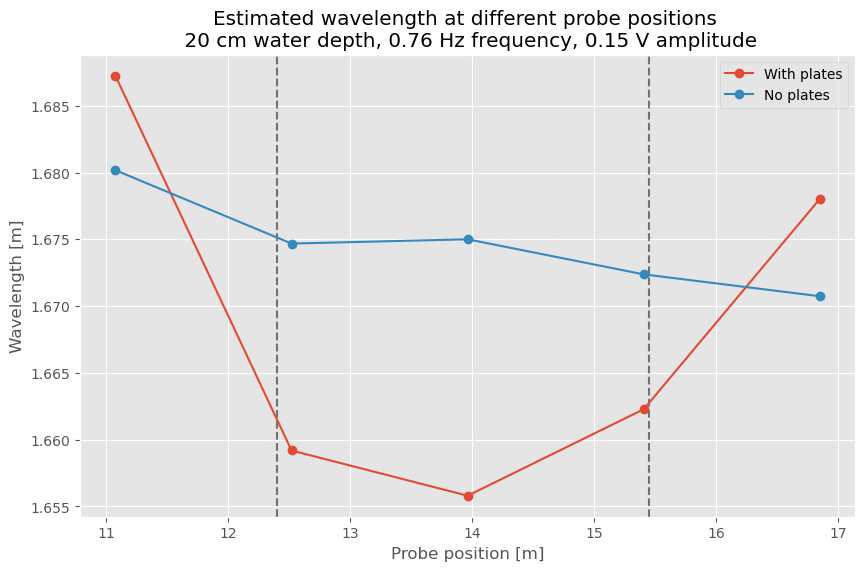

In [61]:
x_wl_plot = np.linspace(x_probe_pos[0], x_probe_pos[-1], 5)

wl_plot = np.array([lamb_pos0, lamb_pos1, lamb_pos2, lamb_pos3, lamb_pos4])
wl_plot_no = np.array([lamb_pos0_no, lamb_pos1_no, lamb_pos2_no, lamb_pos3_no, lamb_pos4_no])

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvline(beach_start, color= 'black', alpha=0.5, linestyle='--')
ax.axvline(beach_end, color='black', alpha=0.5, linestyle='--')

ax.plot(x_wl_plot, wl_plot, marker='o', linestyle='-', label='With plates')
ax.plot(x_wl_plot, wl_plot_no, marker='o', linestyle='-', label='No plates')

ax.set_xlabel('Probe position [m]')
ax.set_ylabel('Wavelength [m]')
ax.set_title('Estimated wavelength at different probe positions \n 20 cm water depth, 0.76 Hz frequency, 0.15 V amplitude')
ax.legend()

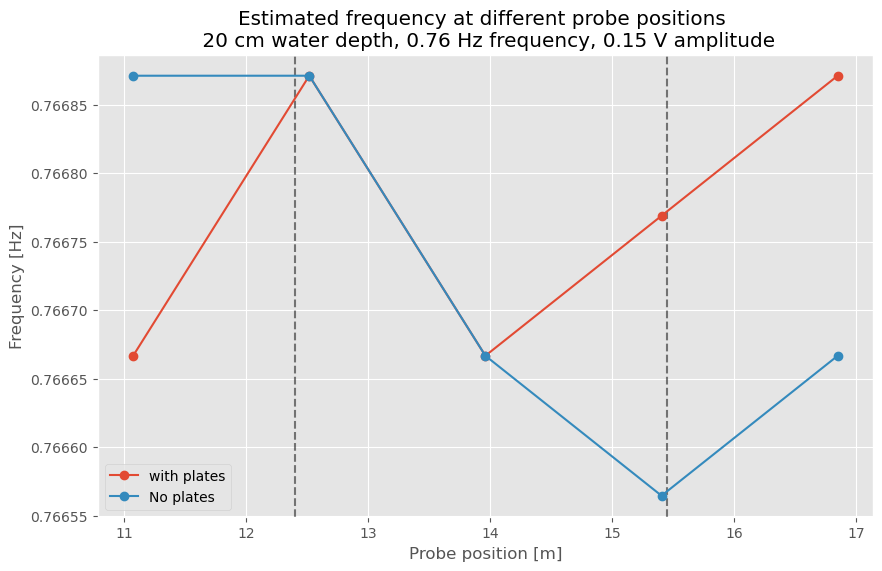

In [62]:
x_fl_plot = np.linspace(x_probe_pos[0], x_probe_pos[-1], 5)

fl_plot = np.array([f_pos0, f_pos1, f_pos2, f_pos3, f_pos4])
fl_plot_no = np.array([f_pos0_no, f_pos1_no, f_pos2_no, f_pos3_no, f_pos4_no])

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvline(beach_start, color= 'black', alpha=0.5, linestyle='--')
ax.axvline(beach_end, color='black', alpha=0.5, linestyle='--')

ax.plot(x_fl_plot, fl_plot, marker='o', linestyle='-', label='with plates')
ax.plot(x_fl_plot, fl_plot_no, marker='o', linestyle='-', label='No plates')

ax.set_xlabel('Probe position [m]')
ax.set_ylabel('Frequency [Hz]')
ax.set_title('Estimated frequency at different probe positions \n 20 cm water depth, 0.76 Hz frequency, 0.15 V amplitude')
ax.legend()

In [63]:
c_pos0 = phase_speed(lamb_pos0, f_pos0)
c_pos0_no = phase_speed(lamb_pos0_no, f_pos0_no)
c_pos1 = phase_speed(lamb_pos1, f_pos1)
c_pos1_no = phase_speed(lamb_pos1_no, f_pos1_no)
c_pos2 = phase_speed(lamb_pos2, f_pos2)
c_pos2_no = phase_speed(lamb_pos2_no, f_pos2_no)
c_pos3 = phase_speed(lamb_pos3, f_pos3)
c_pos3_no = phase_speed(lamb_pos3_no, f_pos3_no)
c_pos4 = phase_speed(lamb_pos4, f_pos4)
c_pos4_no = phase_speed(lamb_pos4_no, f_pos4_no)

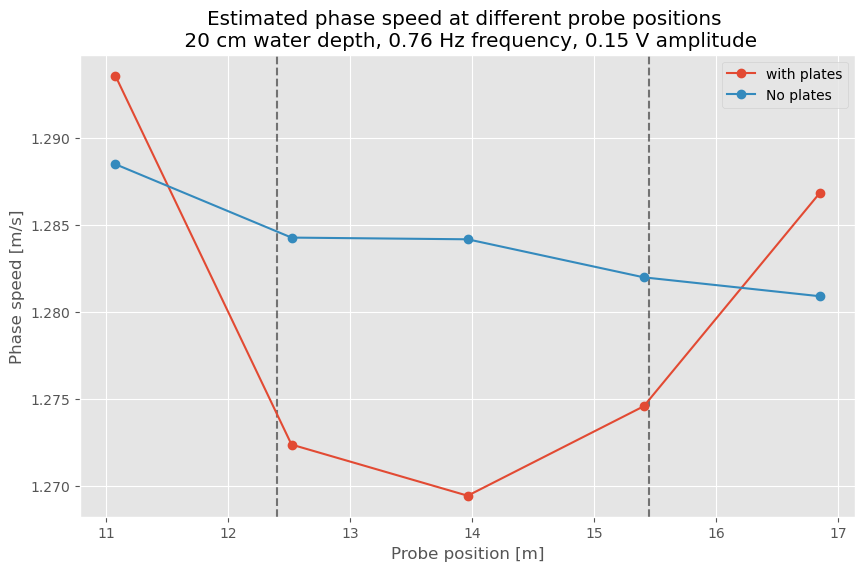

In [64]:
x_c_plot = np.linspace(x_probe_pos[0], x_probe_pos[-1], 5)

c_plot = np.array([c_pos0, c_pos1, c_pos2, c_pos3, c_pos4])
c_plot_no = np.array([c_pos0_no, c_pos1_no, c_pos2_no, c_pos3_no, c_pos4_no])

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvline(beach_start, color= 'black', alpha=0.5, linestyle='--')
ax.axvline(beach_end, color='black', alpha=0.5, linestyle='--')

ax.plot(x_c_plot, c_plot, marker='o', linestyle='-', label='with plates')
ax.plot(x_c_plot, c_plot_no, marker='o', linestyle='-', label='No plates')

ax.set_xlabel('Probe position [m]')
ax.set_ylabel('Phase speed [m/s]')
ax.set_title('Estimated phase speed at different probe positions \n 20 cm water depth, 0.76 Hz frequency, 0.15 V amplitude')
ax.legend()

In [65]:
pos0["time"].iloc[-1]

'2014-01-01 01:00:16.540'

In [66]:
pos0['time'] = pd.to_datetime(pos0['time'])
total_time = (pos0['time'].iloc[-1] - pos0['time'].iloc[0]).total_seconds()
dt = total_time / len(pos0['time'])

In [67]:
dt

0.003999466737768298

In [68]:
#amp_test = calculate_amplitude_from_dataframe(pos0)

In [69]:
std_with = []
positions = [pos0, pos1, pos2, pos3, pos4]

for pos in positions:
    std_p1 = pos['p1'].std()
    std_p2 = pos['p2'].std()
    std_p3 = pos['p3'].std()
    std_p4 = pos['p4'].std()

    std_with.append(std_p1)
    std_with.append(std_p2)
    std_with.append(std_p3)
    std_with.append(std_p4)

In [70]:
std_no = []
positions = [pos0_no, pos1_no, pos2_no, pos3_no, pos4_no]

for pos in positions:
    std_p1 = pos['p1'].std()
    std_p2 = pos['p2'].std()
    std_p3 = pos['p3'].std()
    std_p4 = pos['p4'].std()

    std_no.append(std_p1)
    std_no.append(std_p2)
    std_no.append(std_p3)
    std_no.append(std_p4)

In [71]:
coeff_with = np.polyfit(x_probe_pos, std_with, 1)  
line_with = np.poly1d(coeff_with)            

coeff_no = np.polyfit(x_probe_pos, std_no, 1) 
line_no = np.poly1d(coeff_no) 

In [72]:
coeff_no

array([-7.58423469e-05,  3.28641904e-03])

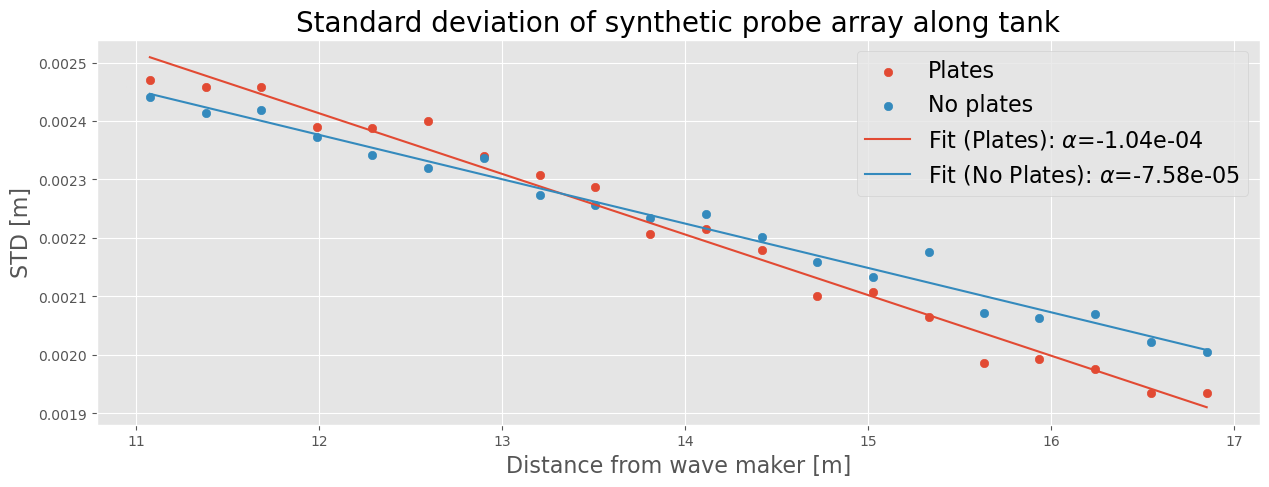

In [73]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.scatter(x_probe_pos, std_with, label='Plates')
ax.scatter(x_probe_pos, std_no, label='No plates')

ax.plot(x_probe_pos, line_with(x_probe_pos), label=rf'Fit (Plates): $\alpha$={coeff_with[0]:.2e}')
ax.plot(x_probe_pos, line_no(x_probe_pos), label=rf'Fit (No Plates): $\alpha$={coeff_no[0]:.2e}')

ax.set_xlabel('Distance from wave maker [m]', fontsize=16)
ax.set_ylabel('STD [m]', fontsize=16)

ax.set_title('Standard deviation of synthetic probe array along tank', fontsize=20)
ax.legend(fontsize=16)

fig.savefig("/Users/kjesta/Desktop/Master prosjekt/Master_code/Figures/STD_print_f076_A015_H02.png", dpi=200, bbox_inches="tight")